# "From-scratch" regional simulation with biogeochemistry (template)
This notebook serves as a **template** with everything needed to create a simulation of any geographic region from scratch, including the creation of all compile-time model options files, compilation and running of the model. **It does not go into detail** about these steps, and should serve more as a tool for quickly prototyping ROMS configurations. For more detailed descriptions of the steps taken here, as well as more advanced applications, see the tutorial on nested simulations with carbon dioxide removal interventions, where a pre-defined configuration is already provided and walked through. Additionally, further details on generating ROMS input files using python (as is done here) can be found in the `roms-tools` [documentation](https://roms-tools.readthedocs.io/).

To use this notebook interactively, copy it from `$ROMS_ROOT/docs/tutorials/from_scratch_bgc_simulation.ipynb` to the directory in which your simulation is to be configured.

## Requirements
This notebook requires an install of the `roms-tools` python package, as well as `jupyter` to run this page as a notebook. Additionally, a selection of datasets are required to use `roms-tools`. For more information on these datasets, see the corresponding `roms-tools` [documentation page](https://roms-tools.readthedocs.io/en/latest/datasets.html). The first cell below sets paths to these datasets once they have been downloaded. If you adjust it to point to your own copies of these data, the rest of the notebook should run.

To use this notebook interactively, simply copy it to any directory where you wish to configure a ROMS simulation and adjust the below cell.

**This cell imports dependencies and sets paths to required datasets:**

In [1]:
%matplotlib inline
import roms_tools as rt
from pathlib import Path
import datetime as dt

# ROMS tools source data:
rtd=Path("~/Code/roms_tools_datasets")

topo_path = rtd/"SRTM15_V2.5.nc" # Topography (SRTM15)
era5_path = [rtd/"ERA5_2012-01.nc", rtd/"ERA5_2012-02.nc"] # Surface forcing (ERA5)
glorys_paths = [rtd/f"GLORYS/mercatorglorys12v1_gl12_mean_201201{d:02}.nc" for d in range(1,32)][:-2] # Interior state for initial and boundary conditions (GLORYS)

# Set if your run will include tides
tpxo_path = rtd/"TPXO10.v2/" # Tidal forcing (TPXO)\

# Set if your run will include biogeochemistry:
bgc_path = rtd/"BGC/BGCdataset.nc" # BGC tracers for initial and boundary conditions (CWorthy unified BGC dataset)
bgc_surf_path = rtd/"BGC/BGCdataset.nc" # BGC surface forcing (CWorthy unified BGC dataset)


OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


**This cell sets up the current directory up for our simulation:**

In [2]:
%%bash
mkdir input_data
mkdir output
cp $ROMS_ROOT/Work/Makefile .
cp $ROMS_ROOT/tests/bgc_real/marbl_* .

## General Parameters
**This cell sets as variables all the parameters we may wish to set for our simulation, for re-use later. Change it as required:**

In [3]:
# Domain, resolution, and parallel processing:
DOMAIN_N_LEVELS = 10
DOMAIN_N_X_POINTS = 96
DOMAIN_N_Y_POINTS = 96
N_PROCESSORS_X = 3
N_PROCESSORS_Y = 3

# Simulation timing
SIMULATION_START_TIME = dt.datetime(2012,1,1,0,0,0)
SIMULATION_END_TIME = dt.datetime(2012,1,10,0,0,0)
SIMULATION_TIME_STEP = 360 #seconds

# Simulation options
INCLUDE_TIDES = True
INCLUDE_RIVERS = True
INCLUDE_BIOGEOCHEMISTRY = True

# Output controls
OUTPUT_FREQUENCY = 86400 # (seconds)
OUTPUT_TYPE = "snapshot" # ("average" or "snapshot")
RESTART_FREQUENCY = 86400 * 5 # (seconds) How often to create a model restart file

INCLUDE_BIOGEOCHEMISTRY_OUTPUT = True # Include the ~31 BGC tracers in the output
INCLUDE_BIOGEOCHEMISTRY_DIAGNOSTIC_OUTPUT = True # Include ~300 BGC-related diagnostic fields in the output
INCLUDE_PHYSICS_OUTPUT = True # Include the physical state variables (u,v,w,T,S) in the output

In [4]:
# Initializing some other variables we will use:

forcing_paths = [] # List of paths to the model forcing files we will create
output_paths = {}  # Dictionary of all output paths (incl. grid and initial conditions, not just forcing)

**The below cells create netCDF and compile-time configuration files for our simulation:**

## Creating a model grid
**This cell sets up the simulation domain. It is the only remaining cell you should need to edit to customize your run:**

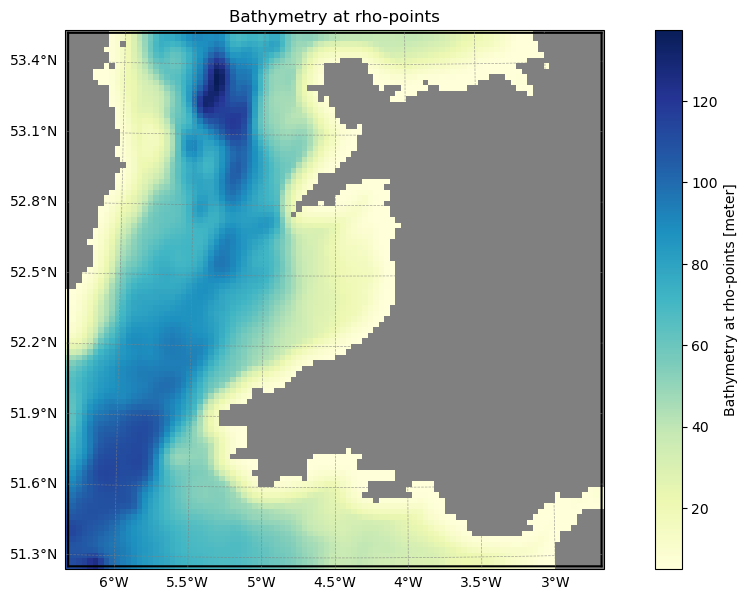

In [5]:
grid = rt.Grid(
                        N  = DOMAIN_N_LEVELS,        # Vertical levels
                        nx = DOMAIN_N_X_POINTS,      # Points in x direction
                        ny = DOMAIN_N_Y_POINTS,      # Points in y direction
                        size_x = 250,                # Geographic extent of the domain in x (km)
                        size_y = 250,                # Geographic extent of the domain in y (km)
                        center_lon = -4.5,           # Center longitude
                        center_lat = 52.4,            # Center latitude
                        rot = 0,                      # Rotation
                        topography_source = {         # Source topography data
                            "name": "SRTM15",
                            "path": str(topo_path),
                        }
                    )
grid.plot()

In [6]:
# Save grid data
grid_path    = grid.save("input_data/grid.nc")
output_paths = {"grid" : grid_path}

2026-03-19 18:01:56 - INFO - Writing the following NetCDF files:
input_data/grid.nc


## Creating bulk forcing

In [7]:
# Physical surface forcing
surface_bulk_forcing = rt.SurfaceForcing(
    grid = grid,
    start_time = SIMULATION_START_TIME,
    end_time = SIMULATION_END_TIME,
    type= "physics",
    source={"name": "ERA5", "path": era5_path},
    use_dask=True,
)

2026-03-19 18:01:56 - WARNING - No records found before the start_time: 2012-01-01 00:00:00.
2026-03-19 18:01:56 - INFO - Data will be interpolated onto the grid coarsened by factor 2. Remember to set `interp_frc = 1` in your `bulk_frc.opt` ROMS option file.


In [8]:
# Save to netCDF
surface_bulk_forcing_path = surface_bulk_forcing.save("input_data/surface_bulk_forcing.nc", group=False)
output_paths["surface_bulk_forcing"] = surface_bulk_forcing_path
forcing_paths.extend(surface_bulk_forcing_path)

2026-03-19 18:02:00 - INFO - Writing the following NetCDF files:
input_data/surface_bulk_forcing.nc


[########################################] | 100% Completed | 9.58 ss


**This cell creates an options file (`bulk_frc.opt`), included in ROMS at compile time, setting bulk-forcing-related parameters:**

In [9]:
with open("bulk_frc.opt","w") as F:
    F.write(f"""
      ! ***************************************************************
      ! User inputs, make sure that units in the forcing files match!

      ! Interpolate forcing from coarser input grid (=1) or not (=0)
      integer :: interp_frc = {int(surface_bulk_forcing.use_coarse_grid)} ! Factor 2 only for now

      logical :: do_check_units=.false.                  ! check units of input vars

      ! Type ncforce contains all required netcdf variables and input data array for frc variable.
      ! Set the name and tname of variable to match what is in the input forcing files.
      ! Use same name as bulk_frc variable name, e.g. uwnd has nc_uwnd for netcdf vars.

      type (ncforce) :: nc_uwnd  = ncforce(vname='uwnd', tname='time' )  ! u-wind (input data in m/s at 10m)
      type (ncforce) :: nc_vwnd  = ncforce(vname='vwnd', tname='time' )  ! v-wind (input data in m/s at 10m)

      type (ncforce) :: nc_tair  = ncforce(vname='Tair', tname='time' )  ! Air temp (input data Degrees C at 2m)
      type (ncforce) :: nc_Q     = ncforce(vname='qair', tname='time' )  ! Q (Specific humidity (kg/kg)
      type (ncforce) :: nc_prate = ncforce(vname='rain', tname='time' )  ! Precipitation rate (cm/day)
      type (ncforce) :: nc_lwrad = ncforce(vname='lwrad',tname='time' )  ! Downward longwave radiation [W/m^2]
      type (ncforce) :: nc_swrad = ncforce(vname='swrad',tname='time' )  ! net shortwave radiation [W/m^2]

#if defined TAU_CORRECTION
      type (ncforce)  :: nc_taux = ncforce(vname='TauX_corr',tname='Taucorr_time'  )  ! The TAU_CORRECTION flag is used to active a correction term to
      type (ncforce)  :: nc_tauy = ncforce(vname='TauY_corr',tname='Taucorr_time'  )  ! bring bulk force field closer to that of the measured data.
#endif

      ! End of user inputs
      ! ***************************************************************
""")

## Creating BGC forcing
**This cell generates biogeochemical surface forcing using `roms-tools`**:

In [10]:
if INCLUDE_BIOGEOCHEMISTRY:
    # BGC surface forcing
    surface_bgc_forcing = rt.SurfaceForcing(
        grid=grid,
        start_time = SIMULATION_START_TIME,
        end_time   = SIMULATION_END_TIME,
        source     ={
            "name": "UNIFIED", 
            "path": bgc_surf_path, 
            "climatology":True
        },
        type="bgc",
        use_dask=True,
    )
    surface_bgc_forcing_path = surface_bgc_forcing.save("input_data/bgc_surface_forcing.nc", group=False)
    output_paths["surface_bgc_forcing"] = surface_bgc_forcing_path
    forcing_paths.extend(surface_bgc_forcing_path)

2026-03-19 18:02:10 - WARNING - Optional variables missing (but not critical): ['pco2_air_alt']
2026-03-19 18:02:10 - INFO - Data will be interpolated onto the grid coarsened by factor 2. Remember to set `interp_frc = 1` in your `bgc.opt` ROMS option file.
2026-03-19 18:02:10 - INFO - Writing the following NetCDF files:
input_data/bgc_surface_forcing.nc


[########################################] | 100% Completed | 106.31 ms


## Creating boundary forcing
**This cell generates boundary forcing file using `roms-tools`:**

In [11]:

boundary_phys_forcing = rt.BoundaryForcing(
    grid       = grid,
    start_time = SIMULATION_START_TIME,
    end_time   = SIMULATION_END_TIME,
    source={
        "name": "GLORYS", 
        "path": glorys_paths
    },
    type = "physics",  # "physics" or "bgc"; default is "physics"
    use_dask = True,
    apply_2d_horizontal_fill = True
)

if INCLUDE_BIOGEOCHEMISTRY:
    boundary_bgc_forcing = rt.BoundaryForcing(
        grid       = grid,
        start_time = SIMULATION_START_TIME,
        end_time   = SIMULATION_END_TIME,
        source={
            "name": "UNIFIED", 
            "path": bgc_path, 
            "climatology": True
        },
        type="bgc",
        use_dask=True,
        apply_2d_horizontal_fill = True
    )
    
    boundary_bgc_forcing_path  = boundary_bgc_forcing.save("input_data/bgc_boundary_forcing.nc",group=False)
    output_paths["boundary_bgc_forcing"] = boundary_bgc_forcing_path
    forcing_paths.extend(boundary_bgc_forcing_path)

boundary_phys_forcing_path = boundary_phys_forcing.save("input_data/phys_boundary_forcing.nc",group=False)
output_paths["boundary_phys_forcing"] = boundary_phys_forcing_path
forcing_paths.extend(boundary_phys_forcing_path)



2026-03-19 18:02:11 - INFO - No `boundaries` provided. Using mask-based defaults: {'south': True, 'east': True, 'north': True, 'west': True}
2026-03-19 18:02:11 - WARNING - No records found before the start_time: 2012-01-01 00:00:00.
2026-03-19 18:02:17 - INFO - No `boundaries` provided. Using mask-based defaults: {'south': True, 'east': True, 'north': True, 'west': True}
2026-03-19 18:02:17 - WARNING - Optional variables missing (but not critical): ['Lig', 'DIC_ALT_CO2', 'Alk_ALT_CO2']
2026-03-19 18:02:18 - INFO - Writing the following NetCDF files:
input_data/bgc_boundary_forcing.nc


[########################################] | 100% Completed | 4.47 sms


2026-03-19 18:02:23 - INFO - Writing the following NetCDF files:
input_data/phys_boundary_forcing.nc


[########################################] | 100% Completed | 6.44 ss


## Creating river forcing
**This cell generates river forcing files using `roms-tools`:**

2026-03-19 18:02:30 - INFO - No river indices provided. Identify all rivers within the ROMS domain and assign each of them to the nearest coastal point.
2026-03-19 18:02:30 - INFO - Compute climatology for river forcing.
2026-03-19 18:02:30 - INFO - Writing the following NetCDF files:
input_data/river_forcing.nc


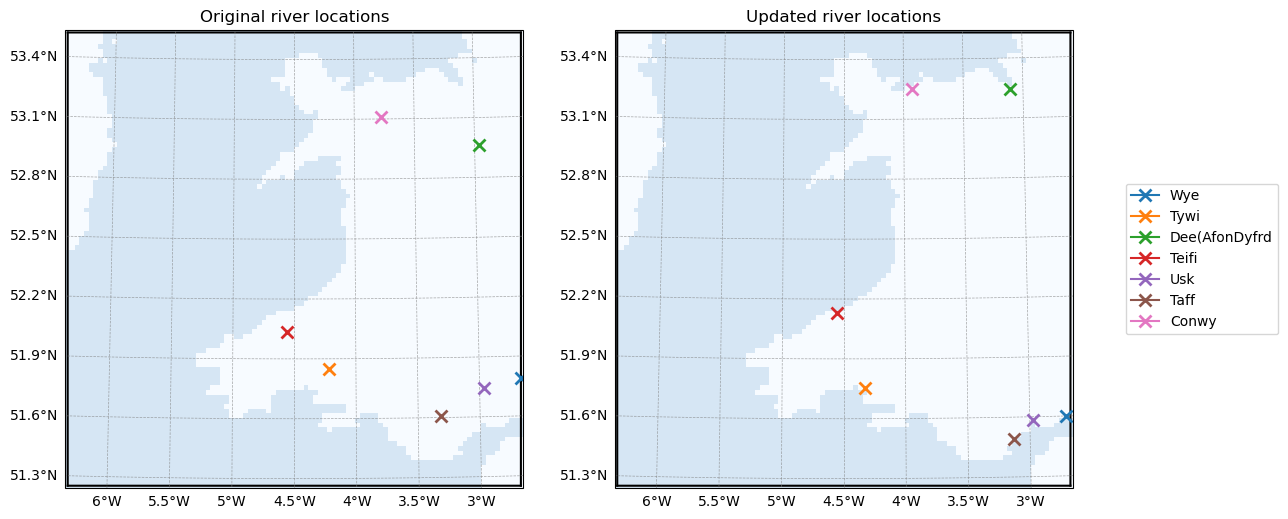

In [12]:
if INCLUDE_RIVERS:
    river_forcing = rt.RiverForcing(
        grid        = grid,
        start_time  = SIMULATION_START_TIME,
        end_time    = SIMULATION_END_TIME,
        include_bgc = INCLUDE_BIOGEOCHEMISTRY,
    )
    river_forcing.plot_locations()
    river_forcing_path = river_forcing.save("input_data/river_forcing.nc")
    output_paths["river_forcing"] = river_forcing_path
    forcing_paths.extend(river_forcing_path)

**This cell creates an options file (`river_frc.opt`), included in ROMS at compile time, setting river-forcing-related parameters:**

In [13]:
if INCLUDE_RIVERS:
    with open("river_frc.opt","w") as F:
        F.write(f"""
          ! ****************************************************************
          ! user inputs
          logical,parameter,public :: river_source = .true.    ! default should be false if not using rivers
          logical,parameter        :: analytical   = .false.   ! analytical forcing, if false then realistic
          integer,public,parameter :: nriv = {river_forcing.ds.sizes.get("nriver")}                 ! number of rivers
    
          ! realistic rivers only: enter netcdf variable name and time name
          type (ncforce) :: nc_rvol = ncforce( vname='river_volume', tname='river_time')
          type (ncforce) :: nc_rtrc = ncforce( vname='river_tracer', tname='river_time')
          ! end user inputs
          ! ****************************************************************
    """)

## Creating tidal forcing
**This cell generates tidal forcing files using `roms-tools`:**

[########################################] | 100% Completed | 102.36 ms


2026-03-19 18:02:33 - INFO - Writing the following NetCDF files:
input_data/tides.nc


[########################################] | 100% Completed | 743.75 ms


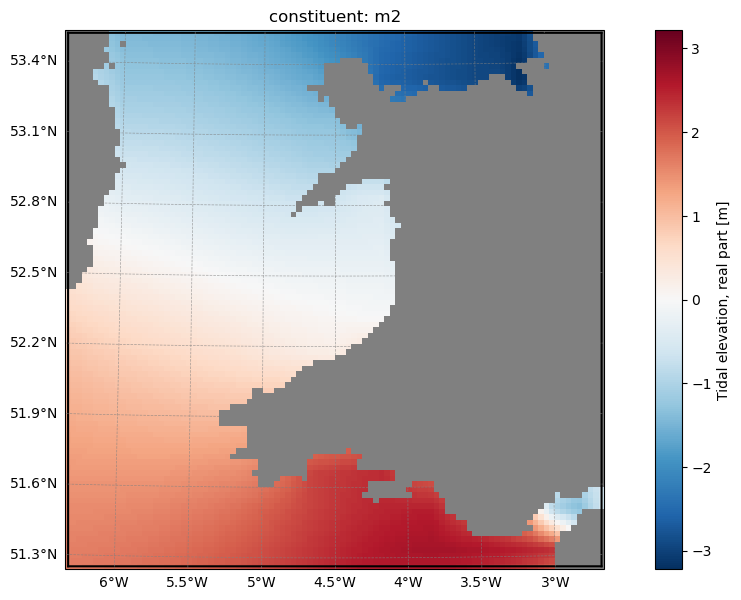

In [14]:
if INCLUDE_TIDES:
    tidal_forcing = rt.TidalForcing(
        grid=grid,
        source={"name": "TPXO", "path": 
                    {
                    "grid": tpxo_path / "grid_tpxo10v2.nc",
                    "h": tpxo_path / "h_tpxo10.v2.nc",
                    "u": tpxo_path / "u_tpxo10.v2.nc",
                    }
               },
        ntides=10, # Number of tidal constituents
        use_dask=True
    )
    tidal_forcing.plot("ssh_Re", ntides=0)
    tidal_forcing_path = tidal_forcing.save("input_data/tides.nc")
    output_paths["tidal_forcing"] = tidal_forcing_path
    forcing_paths.extend(tidal_forcing_path)

**This cell creates an options file, included in ROMS at compile time, setting tidal-forcing-related parameters**

In [15]:
if INCLUDE_TIDES:
    with open("tides.opt","w") as F:
        F.write(
    f"""
          ! ****************************************************************
          ! user inputs
    
          integer,parameter        :: ntides={tidal_forcing.ds.sizes.get("ntides")}         ! Number of tidal components to consider.
          logical,parameter,public :: bry_tides=.false. ! Barotropic tides at the boundary from TPXO
          logical,parameter,public :: pot_tides=.true. ! Surface tidal potential
          logical,parameter,public :: ana_tides=.false. ! Surface tidal potential
    
          ! end user inputs
          ! ****************************************************************
    """)

 ## Creating initial Conditions
 **This cell generates initial conditions from GLORYS reanalysis using `roms-tools`:**

In [16]:
if INCLUDE_BIOGEOCHEMISTRY:
    bgc_source = {
            "name": "UNIFIED",
            "path": bgc_path,
            "climatology": True,
            }
else:
    bgc_source=None

initial_conditions = rt.InitialConditions(
    grid     = grid,
    ini_time = SIMULATION_START_TIME,
    source={"name": "GLORYS", "path": glorys_paths[0]},
    bgc_source = bgc_source,
    use_dask = True,
    allow_flex_time = True # Move the initialization time to the nearest available GLORYS data
)

initial_conditions_path = initial_conditions.save("input_data/initial_conditions.nc")
output_paths["initial_conditions"] = initial_conditions_path

2026-03-19 18:02:34 - WARNING - Selected time entry closest to the specified start_time in +24 hour range: ['2012-01-01T12:00:00.000000000']
2026-03-19 18:02:35 - WARNING - Optional variables missing (but not critical): ['Lig', 'DIC_ALT_CO2', 'Alk_ALT_CO2']
2026-03-19 18:02:36 - INFO - Writing the following NetCDF files:
input_data/initial_conditions.nc


[########################################] | 100% Completed | 3.65 sms


## Other ROMS settings
**This cell creates an options file (`ocean_vars.opt`), included in ROMS at compile time, setting physical model-output-related parameters**

In [17]:
wrt_file_his = ".true." if (INCLUDE_PHYSICS_OUTPUT and OUTPUT_TYPE=="snapshot") else ".false."
wrt_file_avg = ".true." if (INCLUDE_PHYSICS_OUTPUT and OUTPUT_TYPE=="average") else ".false."

with open("ocean_vars.opt","w") as F:
    F.write(f"""
      ! ****************************************************************
      ! user inputs
      logical,parameter :: wrt_file_rst      = .true.     ! t/f to write module history file
      real,parameter    :: output_period_rst = {RESTART_FREQUENCY} ! output period in seconds
      logical,parameter :: monthly_restarts = .false.      ! This overrides output_period

      logical,parameter :: wrt_file_his      = {wrt_file_his}      ! t/f to write module history file
      real,parameter    :: output_period_his = {OUTPUT_FREQUENCY}  ! output period in seconds
      integer,parameter :: nrpf_his          = 10          ! total recs per file
      logical,parameter :: wrt_Z =.true.,
     &                     wrt_Ub=.true.,
     &                     wrt_Vb=.true.,
     &                     wrt_U=.true.,
     &                     wrt_V=.true.,
     &                     wrt_R=.true.,
     &                     wrt_O=.true.,
     &                     wrt_W=.true.,
     &                     wrt_Akv=.true.,
     &                     wrt_Akt=.true.,
     &                     wrt_Aks=.true.,
     &                     wrt_Hbls=.true.,
     &                     wrt_Hbbl=.true.

      logical,parameter :: wrt_file_avg      = {wrt_file_avg}     ! t/f to write module averages file
      real,parameter    :: output_period_avg = {OUTPUT_FREQUENCY} ! output averaging period in seconds
      integer,parameter :: nrpf_avg          = 10          ! total recs per file
      logical,parameter :: wrt_avg_Z =.true.,
     &                     wrt_avg_Ub=.true.,
     &                     wrt_avg_Vb=.true.,
     &                     wrt_avg_U=.true.,
     &                     wrt_avg_V=.true.,
     &                     wrt_avg_R=.true.,
     &                     wrt_avg_O=.true.,
     &                     wrt_avg_W=.true.,
     &                     wrt_avg_Akv=.true.,
     &                     wrt_avg_Akt=.true.,
     &                     wrt_avg_Aks=.true.,
     &                     wrt_avg_Hbls=.true.,
     &                     wrt_avg_Hbbl=.true.

      logical :: code_check = .false.                       ! keep as false unless for code_check
      ! end user inputs
      ! ****************************************************************
""")

**This cell creates an options file (`bgc.opt`), included in ROMS at compile time, setting parameters related to BGC outputs and forcing:**

In [18]:
if INCLUDE_BIOGEOCHEMISTRY:
    wrt_bgc_his = ".true." if (INCLUDE_BIOGEOCHEMISTRY_OUTPUT and OUTPUT_TYPE=="snapshot") else ".false."
    wrt_bgc_avg = ".true." if (INCLUDE_BIOGEOCHEMISTRY_OUTPUT and OUTPUT_TYPE=="average") else ".false."
    wrt_bgc_dia_his = ".true." if (INCLUDE_BIOGEOCHEMISTRY_DIAGNOSTIC_OUTPUT and OUTPUT_TYPE=="snapshot") else ".false."
    wrt_bgc_dia_avg = ".true." if (INCLUDE_BIOGEOCHEMISTRY_DIAGNOSTIC_OUTPUT and OUTPUT_TYPE=="average") else ".false."
    
    with open("bgc.opt","w") as F:
        F.write(f"""
      ! ****************************************************************
      ! User inputs for BGC
      !
      ! ----------------------------------------------------------------
      ! Outputs for bgc tracers and diagnostics of bgc rates
      ! notes : - choice of bgc tracers to output is still selected in tracers.opt.
      !       : - choice of diagnostics to output is in bgc_2Ddiagnostics.opt and bgc_3Ddiagnostics.opt

      logical,parameter :: wrt_his           = {wrt_bgc_his}             ! t/f to write module history file
      real,parameter    :: output_period_his = {OUTPUT_FREQUENCY}                ! output period in seconds
      integer,parameter :: nrpf_his          = 10                 ! total recs per file

      logical,parameter :: wrt_avg           = {wrt_bgc_avg}      ! t/f to write module averages file
      real,parameter    :: output_period_avg = {OUTPUT_FREQUENCY} ! output averaging period in seconds
      integer,parameter :: nrpf_avg          = 10                 ! total recs per file

      logical,parameter :: wrt_his_dia           = {wrt_bgc_dia_his}    ! t/f to write module history file
      real,parameter    :: output_period_his_dia = {OUTPUT_FREQUENCY}            ! output period in seconds
      integer,parameter :: nrpf_his_dia          = 10             ! total recs per file

      logical,parameter :: wrt_avg_dia           = {wrt_bgc_dia_avg}    ! t/f to write module history file
      real,parameter    :: output_period_avg_dia = {OUTPUT_FREQUENCY}   ! output period in seconds
      integer,parameter :: nrpf_avg_dia          = 10             ! total recs per file

      !
      ! ----------------------------------------------------------------
      ! BGC forcing
      !       By default BEC require dust and iron depostion

      integer :: interp_frc  = {int(surface_bgc_forcing.use_coarse_grid)}           ! interpolate forcing from coarser input grid (=1) or not (=0)

      type (ncforce) :: nc_dust        = ncforce(vname='dust', tname='dust_time' )  ! dust forcing
      type (ncforce) :: nc_iron        = ncforce(vname='iron', tname='iron_time' )  ! iron forcing
#ifdef PCO2AIR_FORCING
      type (ncforce) :: nc_pco2air     = ncforce(vname='pco2_air',   tname='pco2_time' )
#ifdef MARBL
      type (ncforce) :: nc_pco2air_alt = ncforce(vname='pco2_air_alt',   tname='pco2_time' )
#endif
#endif
#if defined DAILYPAR_PHOTOINHIBITION || defined DAILYPAR_BEC
      type (ncforce) :: nc_swrad_avg   = ncforce(vname='swrad_LFreq', tname='rad_time_LFreq' )
#endif
#ifdef ALK_SOURCE
      type (ncforce) :: nc_alksource   = ncforce(vname='ALK',   tname='ALK_time' )
#endif
#ifdef NOX_FORCING
      type (ncforce) :: nc_nox        = ncforce(vname='nox', tname='nox_time' )
#endif
#ifdef NHY_FORCING
      type (ncforce) :: nc_nhy        = ncforce(vname='nhy', tname='nhy_time' )
#endif

      ! End of user inputs
      ! *************************************************************

    """)

**This cell creates an options file (`param.opt`), included in ROMS at compile time, setting grid- and parallelization-related parameters:**

In [19]:
with open("param.opt","w") as F:
    F.write(f"""
! Parameter options file

! Dimensions of Physical Grid and array dimensions:
!----------- -- -------- ---- --- ----- -----------
! LLm   Number of the internal points of the PHYSICAL grid in XI-
! MMm   and ETA-directions, excluding physical side boundary points,
!       peroodic ghost points, and MPI-margins (if any).
!
! Domain subdivision parameters:
!------- ----------- -----------
! NP_XI,  NP_ETA     number of MPI subdomains in XI-, ETA-directions;
! NSUB_X, NSUB_E     number of shared memory subdomains (tiles) in XI- and ETA-directions;

! Number of tracers
!------- -----------
! nt  must be 2 or more if Salinity is defined

      integer, parameter :: LLm={DOMAIN_N_X_POINTS}, MMm={DOMAIN_N_Y_POINTS}, N={DOMAIN_N_LEVELS}       ! WEC Example sample grid

      integer, parameter :: NP_XI =  {N_PROCESSORS_X}, NP_ETA = {N_PROCESSORS_Y}
      integer, parameter :: NSUB_X = 1, NSUB_E = 1


      ! Defining number of tracers
      integer, parameter :: nt_passive=0
# ifdef BIOLOGY_BEC2
#   ifdef Ncycle_SY
      integer,parameter :: ntrc_bio=29
#   else
      integer,parameter :: ntrc_bio=26
#   endif
# elif defined MARBL
      integer,parameter :: ntrc_bio=32
# else
      integer,parameter :: ntrc_bio=0
# endif
#ifdef SALINITY
      integer,parameter :: ntrc_salt=1
#else
      integer,parameter :: ntrc_salt=0
#endif

      integer, parameter :: nt=1+nt_passive+ntrc_bio+ntrc_salt
""")

**This cell creates an options file (`cppdefs.opt`) for pre-compilation of ROMS, defining "on-off" switches for model features:**

In [20]:
bgc_cpp = "#define MARBL" if INCLUDE_BIOGEOCHEMISTRY else "#undef MARBL"
riv_cpp = "#define RIVER_SOURCE" if INCLUDE_RIVERS else "#undef RIVER_SOURCE"
tide_cpp = "#define TIDES" if INCLUDE_TIDES else "#undef TIDES"
bgc_dia_cpp = "#define MARBL_DIAGS" if INCLUDE_BIOGEOCHEMISTRY_DIAGNOSTIC_OUTPUT else "#undef MARBL_DIAGS"

with open("cppdefs.opt","w") as F:
    F.write(f"""
/* This is "cppdefs.opt": MODEL CONFIGURATION FILE
   ==== == ============ ===== ============= ==== */

/*
 * CHOOSE ONLY ONE PRIMARY FLAG FOR SWITCH LIST BELOW
 */

#define TUTORIAL_CONFIGURATION


#if defined TUTORIAL_CONFIGURATION

{tide_cpp}
# define BULK_FRC
# define SPONGE_TUNE
{riv_cpp}

# define SOLVE3D
# define UV_COR
# define UV_ADV

# define CURVGRID
# define SPHERICAL
# define MASKING

# define SALINITY
# define NONLIN_EOS
# define SPLIT_EOS

!#define AVERAGES
# define EXACT_RESTART
# define IMPLICIT_BOTTOM_DRAG

# define UV_VIS2
# define TS_DIF2

# define LMD_MIXING
# define LMD_KPP
# define LMD_BKPP
# define LMD_RIMIX
# define LMD_NONLOCAL
!#define LMD_CONVEC

# define OBC_WEST
# define OBC_EAST
# define OBC_NORTH
# define OBC_SOUTH

# define OBC_M2FLATHER  /* Barotop. BC: OBC_M2FLATHER, OBC_M2ORLANSKI, OBC_M2SPECIFIED */
# define OBC_M3ORLANSKI /* Baroclin. BC: OBC_M3ORLANSKI, OBC_M3SPECIFIED */
# define OBC_TORLANSKI  /* Tracer BC: OBC_TORLANSKI, OBC_TSPECIFIED */

# define Z_FRC_BRY
# define M2_FRC_BRY
# define M3_FRC_BRY
# define T_FRC_BRY
# define SPONGE

                        /* Biology Settings */
{bgc_cpp}


#ifdef MARBL
# define NOX_FORCING
# define NHY_FORCING
{bgc_dia_cpp}
#endif

#if defined(BIOLOGY_BEC2) || defined(MARBL)
# define PCO2AIR_FORCING
#endif


#endif


#include "set_global_definitions.h"


""")


**This cell creates a runtime settings file (`roms.in`), defining any settings that do not need to be specified when ROMS is compiled:**

In [21]:
N_TIME_STEPS = int((SIMULATION_END_TIME-SIMULATION_START_TIME).total_seconds()/SIMULATION_TIME_STEP)
with open("roms.in","w") as F:
    F.write(f"""
title:
   roms

time_stepping: NTIMES   dt[sec]  NDTFAST  NINFO
               {N_TIME_STEPS}        {SIMULATION_TIME_STEP}       30       1

S-coord: THETA_S,   THETA_B,    hc (m)
          {grid.theta_s}        {grid.theta_b}     {grid.hc}

grid:  filename
     {str(output_paths["grid"][0])}

forcing: filename
     {"\n     ".join([str(p) for p in forcing_paths])}

initial: NRREC  filename
          1
     {str(output_paths["initial_conditions"][0])}

MARBL_biogeochemistry: namelist  tracer_output_list   diagnostic_output_list
      marbl_in
      marbl_tracers_output_list
      marbl_diagnostic_output_list

output_root_name:
     output/roms

lateral_visc:   VISC2,    VISC4    [m^2/sec for all]
                 0.       0.

rho0:
      1027.5

v_sponge:           V_SPONGE [m^2/sec]
                   1.

tracer_diff2: TNU2(1:NT)           [m^2/sec for all]
              0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.

bottom_drag:     RDRG [m/s],  RDRG2,  Zob [m],  Cdb_min, Cdb_max
                  0.E-4       1.0E-3   1.E-2     1.E-4    1.E-2

gamma2:
                  1.D0

ubind: OBC binding velocity scale [m/s]
       0.1

""")

## Compiling the model

In [ ]:
%%bash
make compile_clean
make

_(Cell output hidden due to length)_

## Pre-processing the input data
**The below cells "partition" the input files such that each processor receives one subset of the domain**

In [23]:
all_paths=[];
[all_paths.extend(p) for p in list(output_paths.values())]
filenames = [p.name for p in all_paths]

In [ ]:
for p in filenames:
    !cd input_data; partit {N_PROCESSORS_X} {N_PROCESSORS_Y} {str(p)} 

_(Cell output hidden due to length)_

## Running the model
The below cell was run on a laptop using an environment configured by conda from `$ROMS_ROOT/environments/conda_environment.yml`. Depending on your environment/system, this command may differ (e.g. `mpiexec` or `srun`), and on HPC systems will likely need to be added to a script that is submitted to a job scheduler such as SLURM or PBS. Consult your system's documentation for more information. 

In [ ]:
!mpirun -n {N_PROCESSORS_X*N_PROCESSORS_Y} ./roms roms.in

_(Cell output hidden due to length)_

## Post-processing model output data
**The below cell "joins" the output files, which were generated separately on different subdomains by each processor**

In [ ]:
%%bash
cd output
# We want to loop over the filename stems, so we'll use the `.0.nc` files as a template
for F in *.0.nc;do

    # Get filename stem, e.g.
    # output/roms_bgc.20120101120000.0.nc -> output/roms_bgc.20120101120000
    filename_stem=${F/.0.nc}

    # Skip any `_ext` files, to be addressed separately:
    if [[ "${filename_stem}" == *"_ext."* ]]; then
        continue
    fi

    # wildcard to join all subdomains with this stem
    ncjoin ${filename_stem}.?.nc
done

_(Cell output hidden due to length)_

## Visualizing model output
**The below cell demonstrates that the model has successfully run and produced output, comparing the first and final records in an output file**

If you chose not to output snapshots of model physics above, you will need to change the file path to another output file:

In [27]:
ls output/roms_*.??????????????.nc

output/roms_bgc.20120101120000.nc      output/roms_his.20120101120000.nc
output/roms_bgc_dia.20120101120000.nc  output/roms_rst.20120106120000.nc


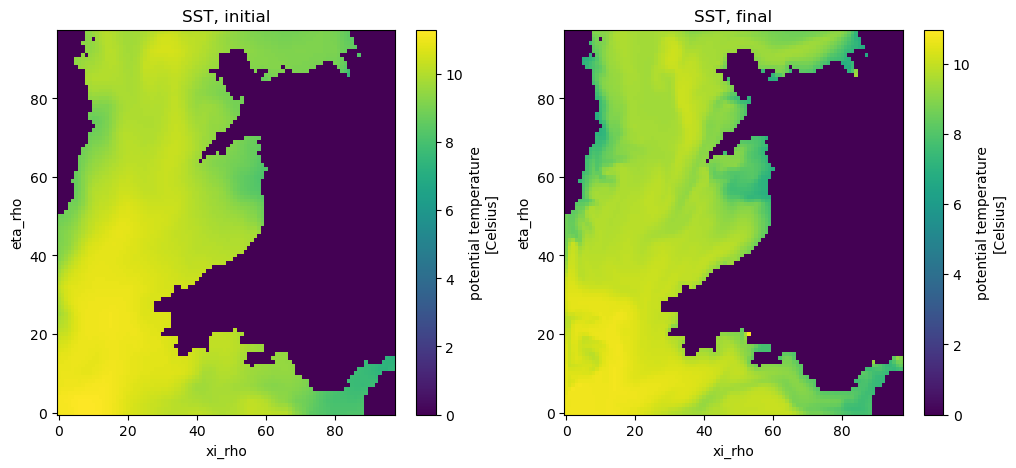

In [28]:
import xarray as xr
import matplotlib.pyplot as plt
DS=xr.open_dataset("output/roms_his.20120101120000.nc")
fig,ax=plt.subplots(1,2)
DS.temp.isel(s_rho=-1,time=0).plot(ax=ax[0]) # s_rho is the vertical co-ordinate, reverse indexed (0 at the bottom, -1 at the surface)
ax[0].set_title("SST, initial")
DS.temp.isel(s_rho=-1,time=-1).plot(ax=ax[1])
ax[1].set_title("SST, final")
fig.set_size_inches(12,5)

## Summary
This tutorial has gone through all of the steps necessary to create and run a ROMS simulation with physics and biogeochemistry, including river and tidal forcing. Rather than going through each step in detail, it is provided as a template to create custom configurations. For more details on each of the steps here, see ROMS' other tutorial on nested simulations with CDR, which acts as a walkthrough for a pre-defined series of simulations, rather than a simpler, customizable notebook.

